# Figure 5: dynamic response

All parameters are dimensionless. $(\gamma_b,\gamma_c,\sigma,\kappa)=(-6,-8,3,0.1)$, $V_0=1$, $\mu=1$.
Run cells from top to bottom. The full 30-realization calculation can take hours; no precomputed data are needed and no files are written.
Meshes relax at $K_V=0$ with fixed box and total volume. Each converged cell volume is then frozen as a target before penalized polishing.
The maximum-force tolerance and negative-eigenvalue threshold are both $10^{-5}$.
Bulk and simple-shear responses use the same equilibria. $h_0$ is the median positive regular Hessian eigenvalue, $\omega_0=\mu h_0$, and $\tau_0=1/\omega_0$.
Bands are pointwise 95% percentile bootstrap intervals (5000 resamples, seed 5009).
The relaxation spectrum uses 50 equal-width bins in $\ln(\tau/\tau_0)$, weighted by $\Delta G_j=\xi_j^2/(A_0h_j)$.
The shaded shoulder window is $0.005\le\omega/\omega_0\le0.025$. The mean shear loss is fitted in log space over $0.05\le\omega/\omega_0\le2.5$, as in Figures S3 and S4; the dotted line and slope $k$ show the fit in panel e.


In [1]:
# Locate the bundled simulator without requiring an editable installation.
from pathlib import Path
import sys
import tomllib

package_root = None
cwd = Path.cwd().resolve()
for candidate in (cwd, *cwd.parents):
    project_file = candidate / "pyproject.toml"
    if project_file.is_file() and (candidate / "cvm3d" / "__init__.py").is_file():
        project = tomllib.loads(project_file.read_text(encoding="utf-8"))
        if project.get("project", {}).get("name") == "epithelial-cvm3d":
            package_root = candidate
            break

if package_root is not None:
    loaded = sys.modules.get("cvm3d")
    if (
        loaded is not None
        and Path(loaded.__file__).resolve().parent != package_root / "cvm3d"
    ):
        raise RuntimeError(
            "Another cvm3d package is loaded. Restart the kernel and run all cells."
        )
    sys.path.insert(0, str(package_root))

import jax

jax.config.update("jax_enable_x64", True)
import numpy as np
import matplotlib.pyplot as plt
from cvm3d.experiments import Parameters, Protocol, prepare_ensemble, measure_ensemble
from cvm3d.plotting import plot_dynamic, plot_individuals

parameters = Parameters()
protocol = Protocol()
seeds = range(100, 130)


Prepared seed 100
Prepared seed 101
Prepared seed 102
Prepared seed 103
Prepared seed 104
Prepared seed 105
Prepared seed 106
Prepared seed 107
Prepared seed 108
Prepared seed 109
Prepared seed 110
Prepared seed 111
Prepared seed 112
Prepared seed 113
Prepared seed 114
Prepared seed 115
Prepared seed 116
Prepared seed 117
Prepared seed 118
Prepared seed 119
Prepared seed 120
Prepared seed 121
Prepared seed 122
Prepared seed 123
Prepared seed 124
Prepared seed 125
Prepared seed 126
Prepared seed 127
Prepared seed 128
Prepared seed 129
Measured seed 100, K_V=10000
Measured seed 101, K_V=10000
Measured seed 102, K_V=10000
Measured seed 103, K_V=10000
Measured seed 104, K_V=10000
Measured seed 105, K_V=10000
Measured seed 106, K_V=10000
Measured seed 107, K_V=10000
Measured seed 108, K_V=10000
Measured seed 109, K_V=10000
Measured seed 110, K_V=10000
Measured seed 111, K_V=10000
Measured seed 112, K_V=10000
Measured seed 113, K_V=10000
Measured seed 114, K_V=10000
Measured seed 115, K_V=10

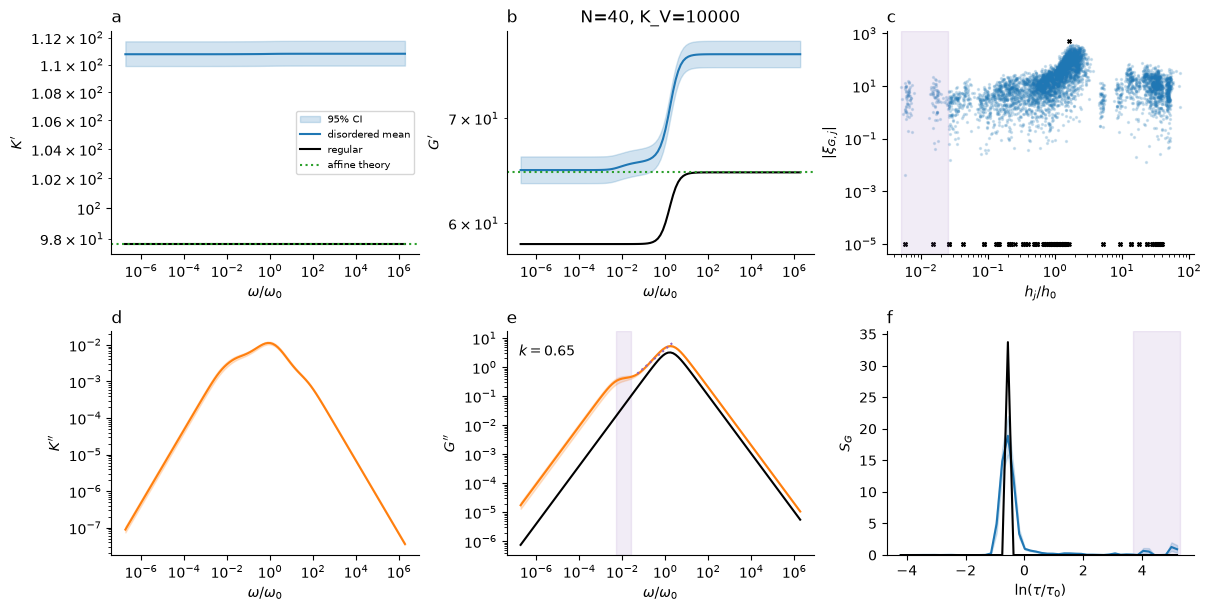

In [2]:
prepared = prepare_ensemble(5, 8, seeds, parameters=parameters, protocol=protocol)
result = measure_ensemble(prepared, volume_penalty=1e4)
fig5 = plot_dynamic([result], fit_window=(0.05, 2.5))


## Figure S5: complex in-plane Poisson ratio

$$\nu^*(\omega)=\frac{K^*(\omega)-G^*(\omega)}{K^*(\omega)+G^*(\omega)}.$$

Reuse the Figure 5 `result` above; no additional relaxation or response calculation is needed.
Bulk and simple-shear moduli share the same equilibria, volume targets, frequency grid,
and reference-area normalization. This is the isotropic effective ratio for each disordered sample.
The solid curve shows $\langle\nu^*\rangle$ with a pointwise 95% bootstrap confidence interval
(5000 resamples, seed 5009). The dashed curve shows
$(\langle K^*\rangle-\langle G^*\rangle)/(\langle K^*\rangle+\langle G^*\rangle)$;
the black curve is the regular reference. Negative imaginary parts are retained.


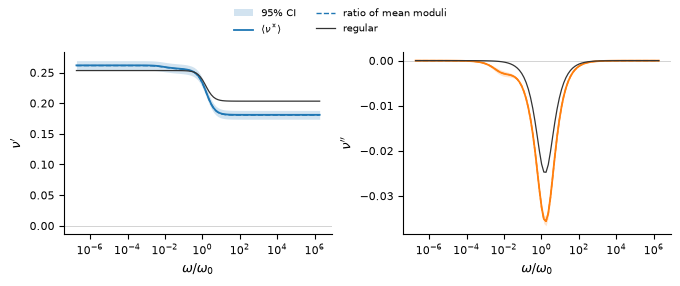

In [3]:
from cvm3d.plotting import mean_band


def complex_poisson_ratio(bulk, shear):
    """Return (K* - G*) / (K* + G*), rejecting undefined ratios."""
    bulk, shear = np.broadcast_arrays(
        np.asarray(bulk, dtype=np.complex128),
        np.asarray(shear, dtype=np.complex128),
    )
    if not (np.all(np.isfinite(bulk)) and np.all(np.isfinite(shear))):
        raise ValueError("Bulk and shear moduli must be finite.")
    denominator = bulk + shear
    tolerance = 64 * np.finfo(float).eps * np.maximum(np.abs(bulk), np.abs(shear))
    if np.any(np.abs(denominator) <= tolerance):
        raise ValueError("K* + G* is zero or numerically cancelling.")
    return (bulk - shear) / denominator


for bulk, shear in zip(result["bulk"], result["shear"], strict=True):
    np.testing.assert_array_equal(bulk.angular_frequencies, result["frequencies"])
    np.testing.assert_array_equal(shear.angular_frequencies, result["frequencies"])
for key in ("regular_bulk", "regular_shear"):
    np.testing.assert_array_equal(
        result[key].angular_frequencies, result["frequencies"]
    )

K_complex = np.stack([response.complex_modulus for response in result["bulk"]])
G_complex = np.stack([response.complex_modulus for response in result["shear"]])
nu_samples = complex_poisson_ratio(K_complex, G_complex)
nu_from_mean_moduli = complex_poisson_ratio(
    K_complex.mean(axis=0), G_complex.mean(axis=0)
)
nu_regular = complex_poisson_ratio(
    result["regular_bulk"].complex_modulus, result["regular_shear"].complex_modulus
)
frequency = result["frequencies"] / result["omega0"]

with plt.rc_context({"font.size": 8, "axes.labelsize": 9, "legend.fontsize": 7}):
    figS5, axes = plt.subplots(
        1, 2, figsize=(170 / 25.4, 70 / 25.4), layout="constrained"
    )
    components = (
        ("real", r"$\nu^{\prime}$", "tab:blue"),
        ("imag", r"$\nu^{\prime\prime}$", "tab:orange"),
    )
    for ax, (part, label, color) in zip(axes, components, strict=True):
        values = getattr(nu_samples, part)
        mean = values.mean(axis=0)
        ax.axhline(0, color="0.8", lw=0.6, zorder=0)
        if len(values) > 1:
            mean, lower, upper = mean_band(values, samples=5000, seed=5009)
            ax.fill_between(
                frequency, lower, upper, color=color, alpha=0.2,
                linewidth=0, label="95% CI",
            )
        ax.plot(frequency, mean, color=color, lw=1.3, label=r"$\langle\nu^*\rangle$")
        ax.plot(
            frequency, getattr(nu_from_mean_moduli, part),
            color=color, ls="--", lw=1, label="ratio of mean moduli",
        )
        ax.plot(
            frequency, getattr(nu_regular, part), color="0.2", lw=0.9,
            label="regular",
        )
        ax.set(xscale="log", xlabel=r"$\omega/\omega_0$", ylabel=label)
        ax.spines[["top", "right"]].set_visible(False)
    handles, labels = axes[0].get_legend_handles_labels()
    figS5.legend(handles, labels, loc="outside upper center", ncol=2, frameon=False)
    plt.show()
